# Notebook 1 — Basic Exploratory Data Analysis
## Kaggle s6e6 Star Class Dataset

> **Dataset:** Kaggle Stellar class `train` data — 577347 instances, 10 features, multinomial classification target (`class`).<br>
> Kaggle Stellar class `test` data — 247435 instances, 10 features. <br>
> **Goal:** Understand the data distribution, missingness patterns, feature relationships, and class imbalance before modelling.

---

## 1. Setup & Imports

We load all required libraries, configure plot aesthetics, detect column names and types, and ingest both the **train** and **test** splits.

**Key loading decisions:**
- Train and test have been processed by base process pipeline, import as parquet. 
- The imported dataframes are the single source of truth.
- All features are float, for numerical, and category, for categorical.


In [38]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent  # or Path.cwd(), or a specific path
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import logging
import shap 

import math
from scipy import stats

import datetime
import json

from utils.utils_reproducibility import set_seed, get_folds
from utils.utils_fit_models import plot_shap_bar, plot_shap_beeswarm, plot_xgb_importance

from config import (
    GlobalConfig, global_cfg,          
    FeatureConfig, features,
    CompetitionConfig, DataConfig, XGBConfig, CVConfig,
    comp_cfg, data_cfg, xgb_cfg, cv_cfg,
    RAW_DIR, PROC_DIR, MODEL_DIR, SUB_DIR, ART_DIR,
    model_logger as log,
    pipeline_logger as pipe_log,
)
from config.env_cfg import make_exp_logger
import os
import joblib

# ── Plot aesthetics ────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11


def import_data(cfg:DataConfig, proc_dir:Path, target:str) \
        -> tuple[pd.DataFrame, pd.DataFrame, list[str], list[str]]:
    """
    Function to import train and test data.
    """
    
    train_path = cfg.train_path(proc_dir)
    test_path  = cfg.test_path(proc_dir)

    df_train = pd.read_parquet(train_path)
    df_test  = pd.read_parquet(test_path)

    # Get feature types
    cats = [c for c in df_train.select_dtypes('category').columns if c != target]
    nums = [c for c in df_train.select_dtypes('float').columns if c != target]
    
    log.info(f"[load] {cfg.train_file}  shape={df_train.shape}")
    log.info(f"[load] {cfg.test_file}   shape={df_test.shape}")
    return df_train, df_test, cats, nums

df_train, df_test, cats, nums = import_data(data_cfg, PROC_DIR, features.target)

assert len(cats+nums) + 1 == df_train.shape[1], 'Data mismatch either df_train or cats and nums'

print(f'Train shape : {df_train.shape}')
print(f'Test shape  : {df_test.shape}')
print(f'Combined    : {df_train.shape[0] + df_test.shape[0]:,} rows, {len(cats+nums)} columns')
print(f'\nTarget labels (unique): {sorted(df_train[features.target].unique())}')


12:52:38  INFO      models        [load] s6e6_star_train_base_20260611.parquet  shape=(577347, 11)
12:52:38  INFO      models        [load] s6e6_star_test_base_20260611.parquet   shape=(247435, 10)


Train shape : (577347, 11)
Test shape  : (247435, 10)
Combined    : 824,782 rows, 10 columns

Target labels (unique): ['GALAXY', 'QSO', 'STAR']


## 2. Dataset Overview
**Description**
The dataset is from the Kaggle playground competition.

**Key facts:**
- **Task:** Classify stars based on measurements.
- **Features:** 8 numerical features + 2 categorical features.
- **Class imbalance:** Target is imvalanced.
- **Fairness research:** No fairness aspects.
- **Caveats:** Kaggle datasets might not refelct true distributions

> 💡 **Industry Practice:** Always read the dataset's provenance documentation before modelling. Understanding *how* data was collected informs which features to trust and where leakage risks lie

In [39]:
display(df_train)

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734253,16.959272,25.472122,21.895559,20.357925,19.257113,18.621058,0.408982,M,Red_Sequence,GALAXY
1,127.988678,32.346718,20.778509,19.087063,17.587208,17.226067,16.786432,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344845,21.035202,21.079128,21.171841,20.582630,20.557365,2.823770,O/B,Blue_Cloud,QSO
3,225.818298,48.569420,23.305056,21.050735,19.017754,18.365658,17.914951,0.536099,M,Red_Sequence,GALAXY
4,141.836136,19.342852,21.703157,19.471680,18.234449,17.899446,17.616184,0.555761,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...
577342,223.539291,2.503680,20.828730,18.854200,17.703108,17.190536,16.551355,0.511524,M,Red_Sequence,GALAXY
577343,223.895966,40.769344,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,52.258926,0.671887,21.944250,21.215857,19.025967,18.772276,18.203396,0.376342,M,Red_Sequence,GALAXY
577345,247.362244,50.659821,21.969881,21.622766,20.987576,20.930923,21.478134,2.868359,G/K,Blue_Cloud,QSO


In [40]:
# Data types
print('=== Column dtypes ===')
df_train.dtypes.to_frame('dtype')

=== Column dtypes ===


,dtype
alpha,float32
delta,float32
u,float32
g,float32
r,float32
i,float32
z,float32
redshift,float32
spectral_type,category
galaxy_population,category


In [41]:
# Categorical vs numerical breakdown
print('Numeric columns  :', nums)
print('Categorical cols :', cats)
print(f'\nTotal features   : {len(nums) + len(cats)} (+ 1 target)')

Numeric columns  : ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Categorical cols : ['spectral_type', 'galaxy_population']

Total features   : 10 (+ 1 target)


=== Target value counts ===
         count   pct%
class                
GALAXY  377480  65.38
QSO     117143  20.29
STAR     82724  14.33
         count  proportion_%  ratio_to_smallest
class                                          
GALAXY  377480         65.38               4.56
QSO     117143         20.29               1.42
STAR     82724         14.33               1.00


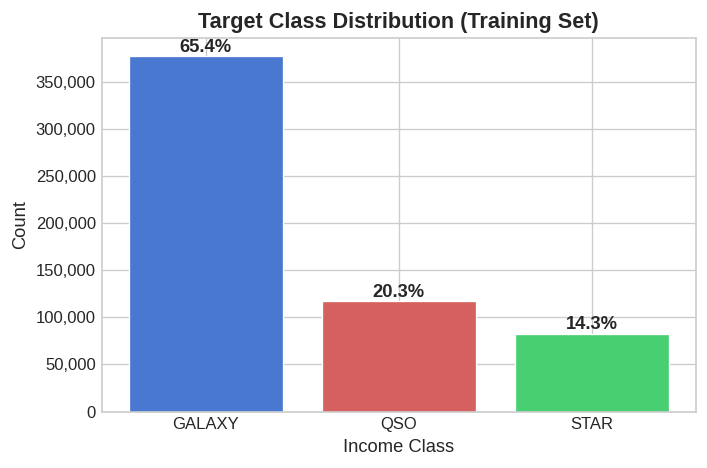

In [42]:
# Target value counts + bar chart with percentage annotations
vc = df_train[features.target].value_counts()
pct = df_train[features.target].value_counts(normalize=True) * 100

print('=== Target value counts ===')
print(pd.concat([vc.rename('count'), pct.round(2).rename('pct%')], axis=1))

# Overall proportions for a 3-class target
vc = df_train[features.target].value_counts()
vc_sorted = vc.sort_index()

prop = (vc_sorted / vc_sorted.sum() * 100).round(2)

baseline = vc_sorted.min()
ratio = (vc_sorted / baseline).round(2)

summary = pd.DataFrame({
    "count": vc_sorted,
    "proportion_%": prop,
    "ratio_to_smallest": ratio,
})

print(summary)

# Plot class counts
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(vc.index, vc.values, color=['#4878CF', '#D65F5F',"#48CF71"], edgecolor='white', linewidth=0.8)

for bar, p in zip(bars, pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{p:.1f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax.set_title('Target Class Distribution (Training Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Income Class')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 3. Missing Value Analysis

Kaggle playground dataset do not have missing values

**Columns with potential missingness:** `No missing values

**Audit approach:**


> 💡 **Industry Practice:** Never drop missing rows until you understand *why* data is missing. MCAR (missing completely at random), MAR (at random), and MNAR (not at random) require different imputation strategies and have different impacts on model bias.

> 📐 **Math Note:** Missing rate for column $j$ is $$m_j = \frac{\#\text{null}_{j}}{N}$$. A threshold of 40–50 % missing is commonly used to decide whether to drop a feature entirely.

In [43]:
# Missing value counts
missing = df_train.isnull().sum()
missing_pct = (df_train.isnull().sum() / len(df_train) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)

print('=== Missing value summary ===')
print(missing_df)
print(f'\nTotal cells with missing data: {df_train.isnull().sum().sum():,}')

=== Missing value summary ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Total cells with missing data: 0


## 4. Check Numerical -> Categorical

In [44]:
num_stats = []
for col in nums:
    s = df_train[col]
    num_stats.append({
        "feature": col,
        "n_unique": s.nunique(),
        "is_integer": bool((s.dropna() % 1 == 0).all()),
        "min": s.min(),
        "max": s.max(),
    })
num_stats_df = pd.DataFrame(num_stats).sort_values("n_unique")
print(num_stats_df)

    feature  n_unique  is_integer        min         max
0     alpha    270395       False   0.011684  359.999817
1     delta    277628       False -17.966988   79.158325
4         r    518510       False  12.579407   25.254499
5         i    520338       False  11.962782   27.910852
6         z    521317       False  11.682803   26.826866
3         g    523249       False  13.535483   27.620207
2         u    535340       False  -0.139225   28.253263
7  redshift    570459       False  -0.009970    7.010780


## 5. Basic Univariate Statistics Summary Table

A consolidated statistics table provides a single-glance summary for all numeric features. This is the canonical artifact to include in a data quality report or model card.

**Columns:**
- `mean`, `median`, `std` — central tendency and spread
- `skew`, `kurtosis` — distribution shape
- `min`, `max` — range (useful for detecting outlier upper bounds)
- `pct_zeros` — for capital-related features, a high zero rate indicates sparse signals

> 💡 **Industry Practice:** Include the `pct_zeros` metric for any feature that might be censored at zero (e.g. capital gains for non-investors). A feature that is 90% zero may need to be split into a binary indicator (`has_capital_gain`) plus a continuous log-transformed value (`log_capital_gain`) — a technique called **two-part modelling**.

In [45]:
def build_univariate_summary(df: pd.DataFrame, numeric_cols: list) -> pd.DataFrame:
    """
    Build a comprehensive univariate statistics summary table.

    Parameters
    ----------
    df : pd.DataFrame
    numeric_cols : list of str

    Returns
    -------
    pd.DataFrame
        Summary statistics indexed by column name.
    """
    rows = []
    for col in numeric_cols:
        s = df[col].dropna()
        rows.append({
            'mean':      round(s.mean(), 3),
            'median':    round(s.median(), 3),
            'std':       round(s.std(), 3),
            'skew':      round(s.skew(), 3),
            'kurtosis':  round(s.kurt(), 3),
            'min':       s.min(),
            'max':       s.max(),
            'pct_zeros': round((s == 0).sum() / len(s) * 100, 2)
        })
    return pd.DataFrame(rows, index=numeric_cols)

summary_table = build_univariate_summary(df_train, nums)

# Styled display
summary_table.style \
    .background_gradient(subset=['skew', 'kurtosis'], cmap='RdYlGn_r') \
    .background_gradient(subset=['pct_zeros'], cmap='Oranges') \
    .format({
        'mean': '{:.2f}', 'median': '{:.2f}', 'std': '{:.2f}',
        'skew': '{:.3f}', 'kurtosis': '{:.3f}',
        'min': '{:.0f}', 'max': '{:.0f}',
        'pct_zeros': '{:.2f}%'
    }) \
    .set_caption('Univariate Statistics Summary — Numeric Features')

,mean,median,std,skew,kurtosis,min,max,pct_zeros
alpha,181.62,188.68,96.24,-0.055,-0.403,0,360,0.00%
delta,21.83,21.48,18.93,0.175,-1.120,-18,79,0.00%
u,22.44,22.57,2.02,-0.117,-0.444,-0,28,0.00%
g,21.01,21.47,1.79,-0.629,-0.292,14,28,0.00%
r,19.96,20.43,1.65,-0.662,-0.451,13,25,0.00%
i,19.38,19.63,1.58,-0.480,-0.477,12,28,0.00%
z,19.04,19.19,1.58,-0.314,-0.438,12,27,0.00%
redshift,0.72,0.50,0.81,2.305,7.055,-0,7,0.00%


## 6. Numerical Feature Distributions

We examine each of the eight numeric features using histograms with KDE overlays, split by class (target).

**Key concepts:**
- **Skewness** measures asymmetry of the distribution. A value near 0 is symmetric; positive skew means a long right tail. <br>
- Highly skewed features (e.g. `redshift`) often benefit from log-transformation before modelling.
- **Kurtosis** measures tail heaviness. High kurtosis = more extreme outliers than a normal distribution.


> 📐 **Math Note:**  
> Skewness: $$\gamma_1 = \frac{1}{N} \sum_i \left(\frac{x_i - \bar{x}}{\sigma}\right)^3$$
> Excess Kurtosis: $$\gamma_2 = \frac{1}{N} \sum_i \left(\frac{x_i - \bar{x}}{\sigma}\right)^4 - 3$$

> 💡 **Industry Practice:** Always overlay class-conditional distributions (not just marginal ones). A feature that looks unremarkable marginally may be highly discriminative when viewed separately for each class — this is the key insight that drives feature selection.

=== Skewness & Kurtosis ===
          skewness  kurtosis
alpha       -0.055    -0.403
delta        0.175    -1.120
u           -0.117    -0.444
g           -0.629    -0.292
r           -0.662    -0.451
i           -0.480    -0.477
z           -0.314    -0.438
redshift     2.305     7.055


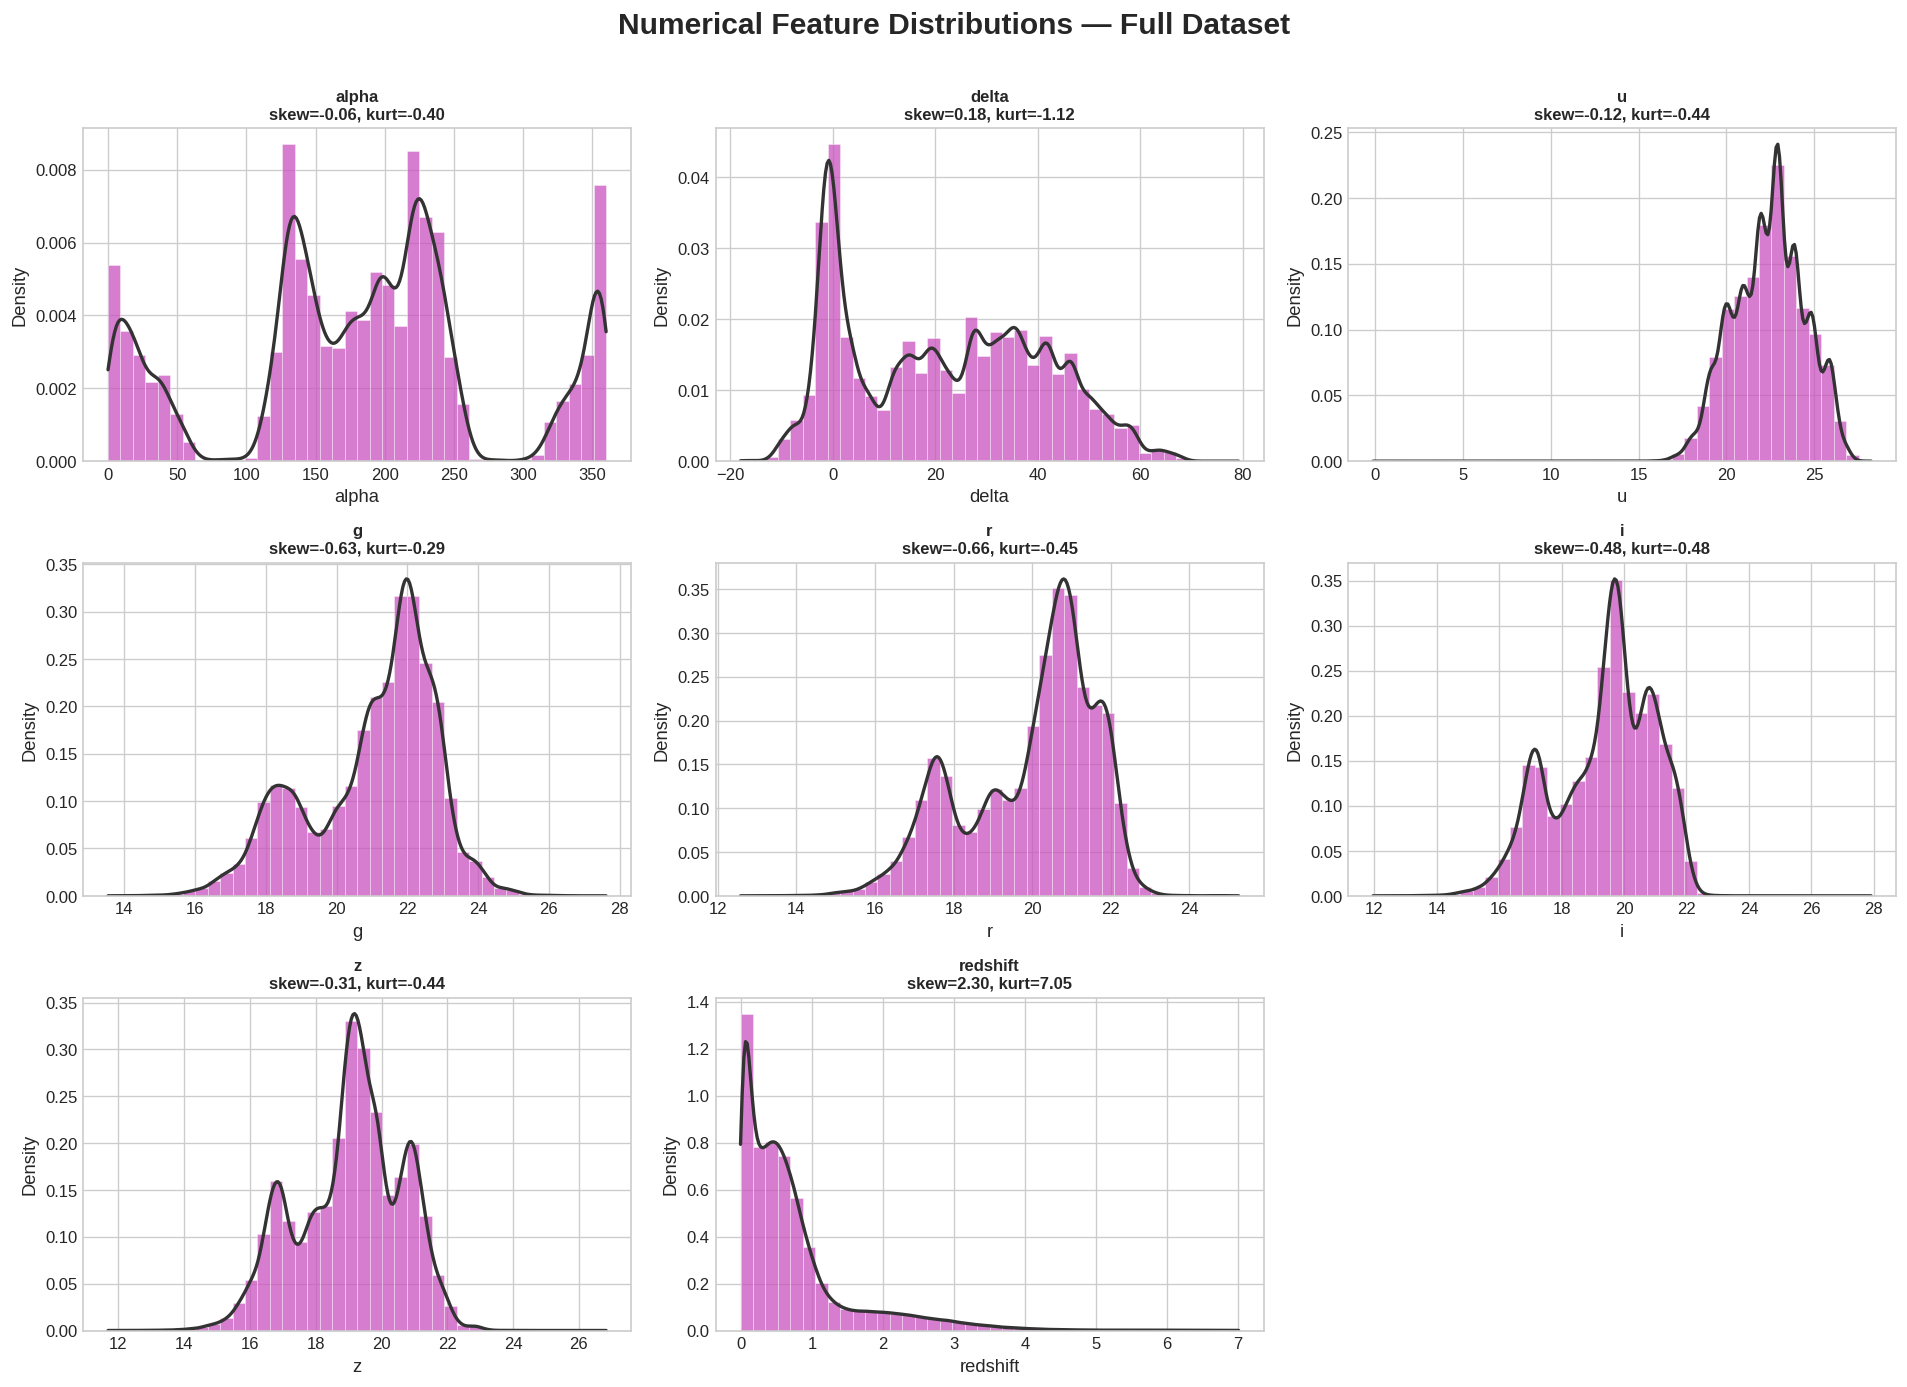

In [46]:
def plot_numeric_distributions_full(
    df: pd.DataFrame,
    numeric_cols: list,
    bins: int = 40,
) -> None:
    """
    Plot a grid of full-dataset numeric feature distributions only.
    Each panel shows one histogram with an overall KDE overlay.
    """
    n_cols = 3
    n_rows = math.ceil(len(numeric_cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.8 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        vals = df[col].dropna()

        # Histogram
        ax.hist(
            vals,
            bins=bins,
            density=True,
            color="#C952BF",
            alpha=0.75,
            edgecolor="white",
            linewidth=0.3,
        )

        # KDE overlay
        if len(vals) > 1 and vals.std() > 0:
            kde_x = np.linspace(vals.min(), vals.max(), 300)
            kde = stats.gaussian_kde(vals)
            ax.plot(kde_x, kde(kde_x), color="#333333", lw=2)

        skew_val = vals.skew()
        kurt_val = vals.kurt()

        ax.set_title(
            f'{col}\nskew={skew_val:.2f}, kurt={kurt_val:.2f}',
            fontsize=10,
            fontweight='bold'
        )
        ax.set_xlabel(col)
        ax.set_ylabel("Density")

    # Hide unused axes
    for j in range(len(numeric_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        "Numerical Feature Distributions — Full Dataset",
        fontsize=18,
        fontweight="bold",
        y=1.01
    )
    plt.tight_layout()
    plt.show()
    
# Print skewness & kurtosis table
print('=== Skewness & Kurtosis ===')
sk_df = pd.DataFrame({
    'skewness': df_train[nums].skew().round(3),
    'kurtosis': df_train[nums].kurt().round(3)
})
print(sk_df)

plot_numeric_distributions_full(df_train, nums)

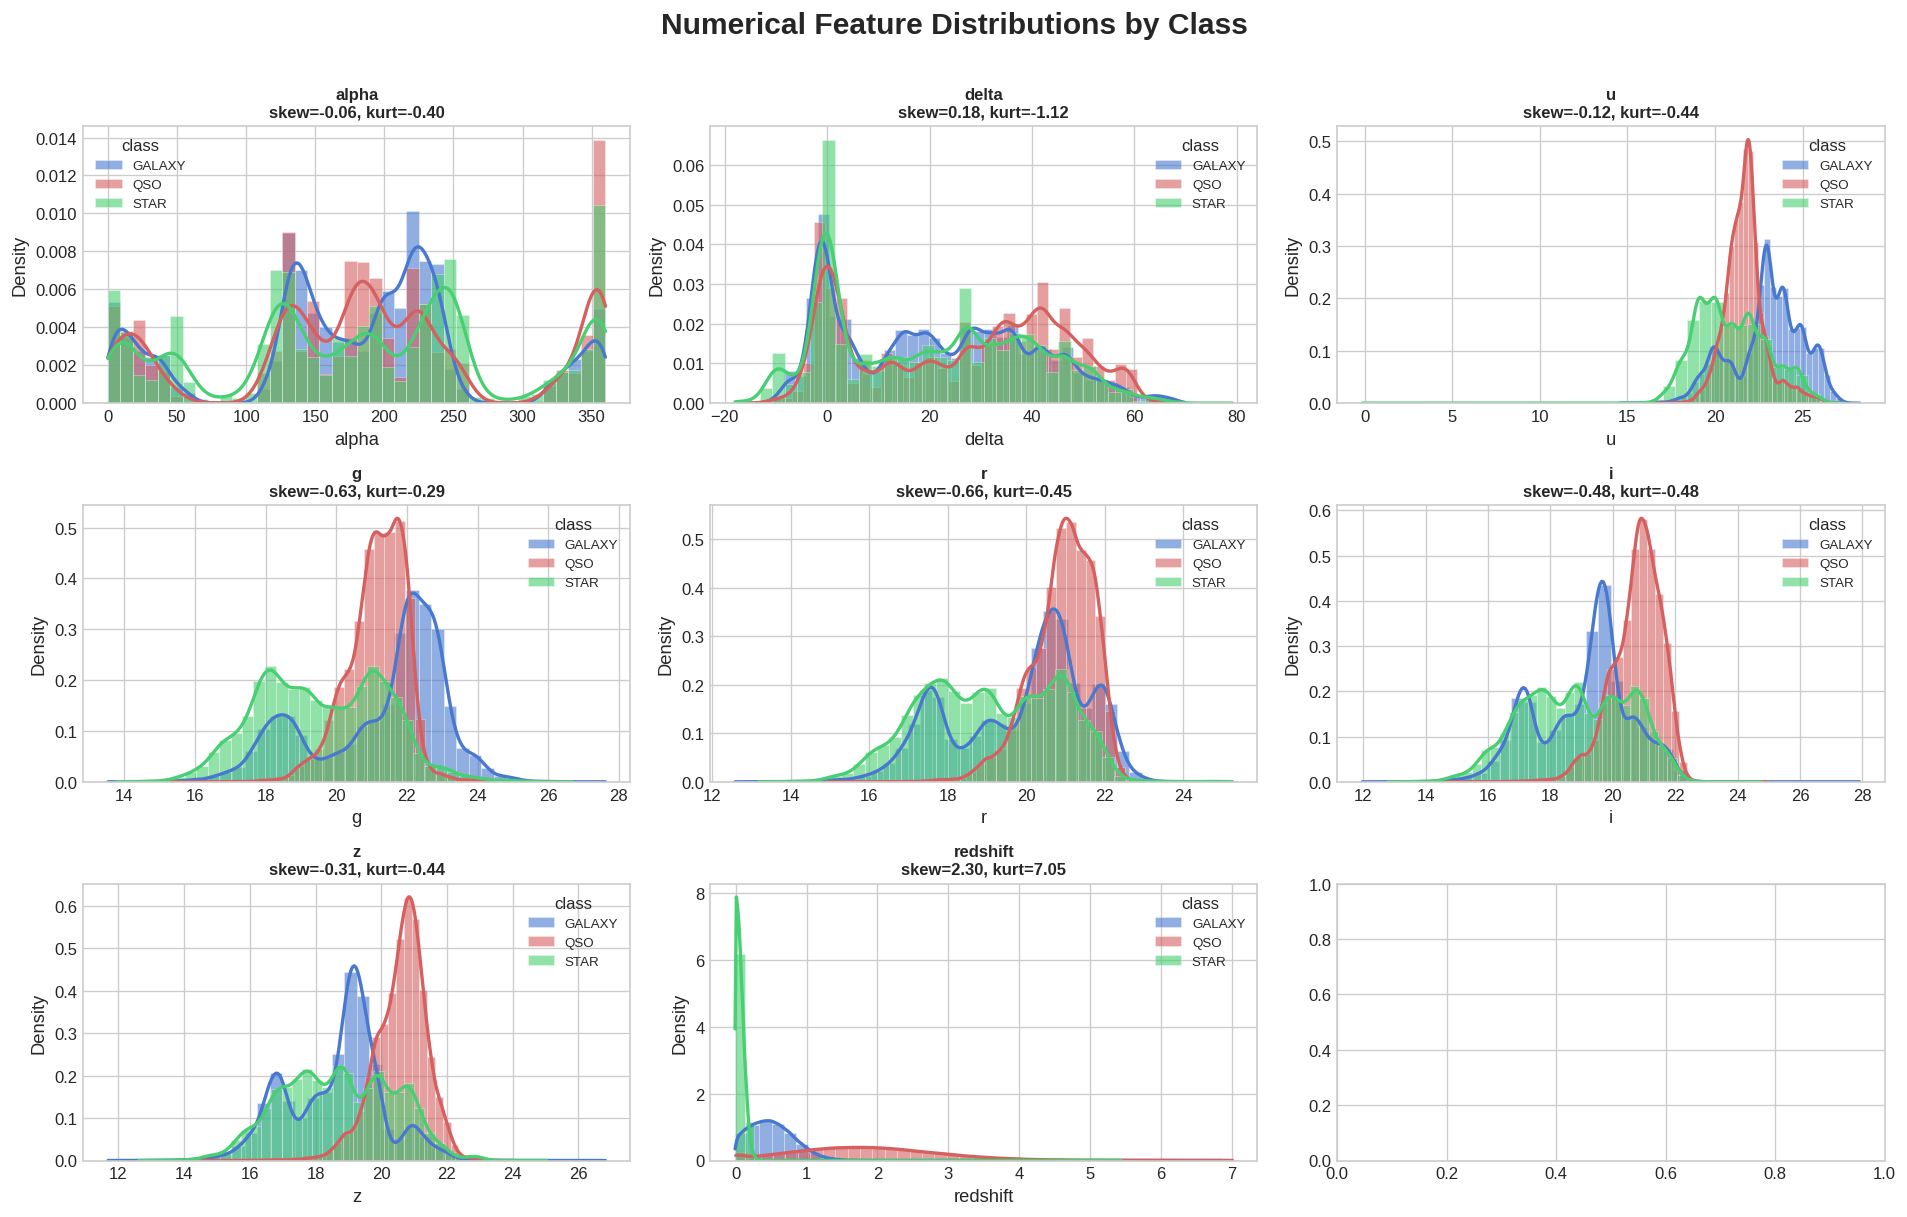

In [47]:
def plot_numeric_distributions(df: pd.DataFrame, numeric_cols: list) -> None:
    """
    Plot 2x3 grid of histograms+KDE for each numeric feature,
    split by target class.

    Parameters
    ----------
    df : pd.DataFrame
    numeric_cols : list of str
    target_col : str
    """
    fig, axes = plt.subplots(3, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    target_names = df_train[features.target].unique()
    target_colors = ['#4878CF', '#D65F5F',"#48CF71"]
    palette = dict(zip(target_names, target_colors))

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        for label, color in palette.items():
            subset = df[df[features.target] == label][col].dropna()
            ax.hist(
                subset, bins=40, alpha=0.6, color=color,
                label=label, density=True, edgecolor='white', linewidth=0.3
            )
            # KDE overlay
            if subset.std() > 0:
                kde_x = np.linspace(subset.min(), subset.max(), 300)
                kde = stats.gaussian_kde(subset)
                ax.plot(kde_x, kde(kde_x), color=color, lw=2)

        skew_val = df[col].skew()
        kurt_val = df[col].kurt()
        ax.set_title(
            f'{col}\nskew={skew_val:.2f}, kurt={kurt_val:.2f}',
            fontsize=10, fontweight='bold'
        )
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        ax.legend(fontsize=8, title=features.target)

    plt.suptitle('Numerical Feature Distributions by Class', fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_numeric_distributions(df_train, nums)

## 7. Categorical Feature Distributions

We examine the frequency distribution of each categorical feature to understand **cardinality** (number of unique values) and the prevalence of rare categories.

**Why cardinality matters:**
- High-cardinality columns are problematic for one-hot encoding — they create wide sparse matrices.
- Rare categories (< 1% frequency) often need to be grouped into an `'Other'` bucket to prevent overfitting.
- Ordinal columns (like `spectral_type`) may benefit from ordinal encoding over one-hot.

> 💡 **Industry Practice:** Inspect value counts *before* encoding. A category with 5 occurrences in 32,000 rows will cause issues at inference time if the model never saw it — target encoding or smoothed estimates handle this more robustly than one-hot.

=== Categorical cardinality ===
                   n_unique     top_value  top_pct
spectral_type             4             M     52.5
galaxy_population         2  Red_Sequence     55.4


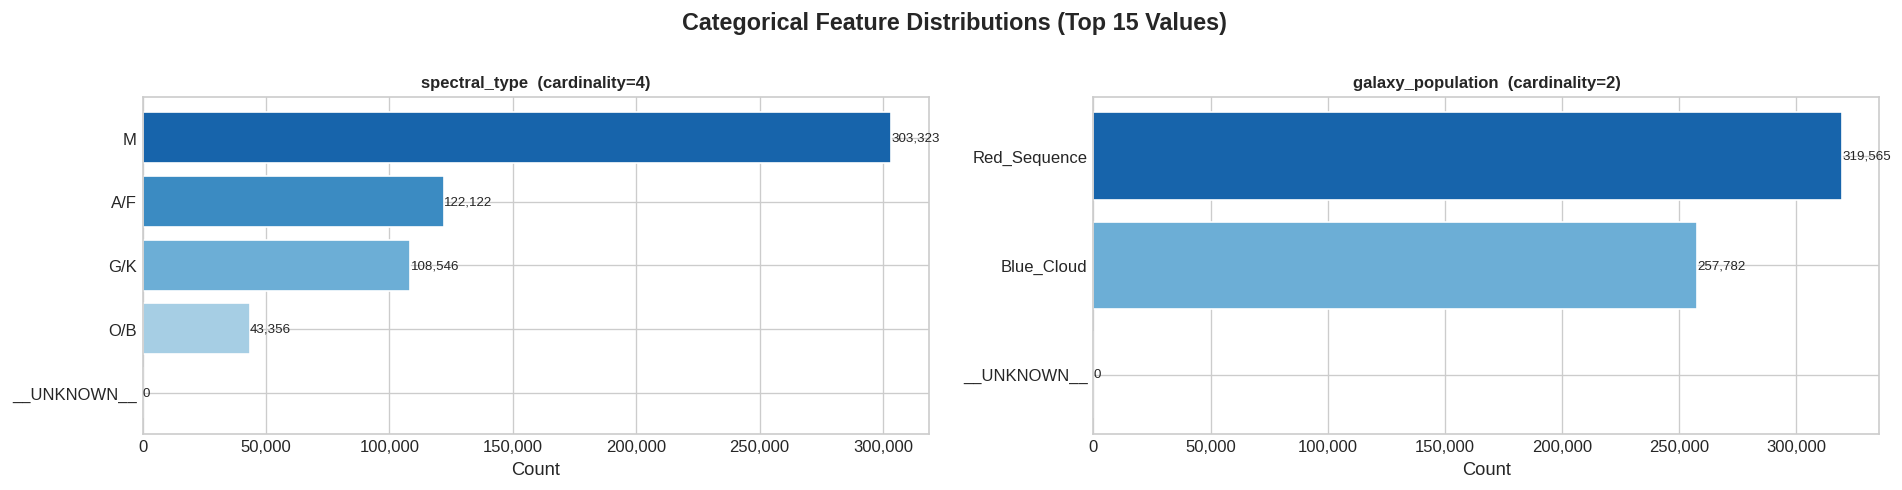

In [48]:
def plot_categorical_distributions(df: pd.DataFrame, cat_cols: list, top_n: int = 15) -> None:
    """
    Plot horizontal bar charts for categorical feature value counts.

    Parameters
    ----------
    df : pd.DataFrame
    cat_cols : list of str
    top_n : int
        Maximum number of categories to show per feature.
    """
    n_cols = 2
    n_rows = (len(cat_cols) + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    axes = axes.flatten()

    cmap = plt.get_cmap('Blues_r')

    for i, col in enumerate(cat_cols):
        ax = axes[i]
        vc = df[col].value_counts().head(top_n)
        n = len(vc)
        colors = [cmap(0.2 + 0.6 * j / max(n - 1, 1)) for j in range(n)]

        ax.barh(vc.index[::-1], vc.values[::-1], color=colors[::-1], edgecolor='white')
        for val, cnt in zip(vc.index[::-1], vc.values[::-1]):
            ax.text(cnt + 20, list(vc.index[::-1]).index(val),
                    f'{cnt:,}', va='center', fontsize=8)
        ax.set_title(f'{col}  (cardinality={df[col].nunique()})', fontweight='bold', fontsize=10)
        ax.set_xlabel('Count')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Hide unused subplots
    for j in range(len(cat_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Categorical Feature Distributions (Top 15 Values)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# Cardinality overview
print('=== Categorical cardinality ===')
card_df = pd.DataFrame({
    'n_unique': [df_train[c].nunique() for c in cats],
    'top_value': [df_train[c].value_counts().index[0] for c in cats],
    'top_pct': [(df_train[c].value_counts(normalize=True).iloc[0] * 100).round(1) for c in cats]
}, index=cats)
print(card_df)

plot_categorical_distributions(df_train, cats)

## 8. Correlation Analysis

**Pearson correlation** measures linear association between two continuous variables. It is appropriate for numeric–numeric pairs but ignores non-linear relationships.


> 📐 **Math Note:**  
> Pearson: \( r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \sum(y_i - \bar{y})^2}} \)  


> 💡 **Industry Practice:** Correlation ≠ causation, and low Pearson $r$ does not imply low predictive power. Tree-based models capture non-linear interactions that correlation analysis misses. Use correlations as a *triage* tool, not a feature selection oracle.

=== ANOVA F-stat + Eta-squared with target "class" ===
                 f_stat  p_value  eta_sq
redshift  352900.687500      0.0  0.5501
z          94881.554688      0.0  0.2474
i          71806.617188      0.0  0.1992
u          51307.917969      0.0  0.1509
r          36471.257812      0.0  0.1122
g          33737.925781      0.0  0.1046
delta       3412.798340      0.0  0.0117
alpha        631.117004      0.0  0.0022


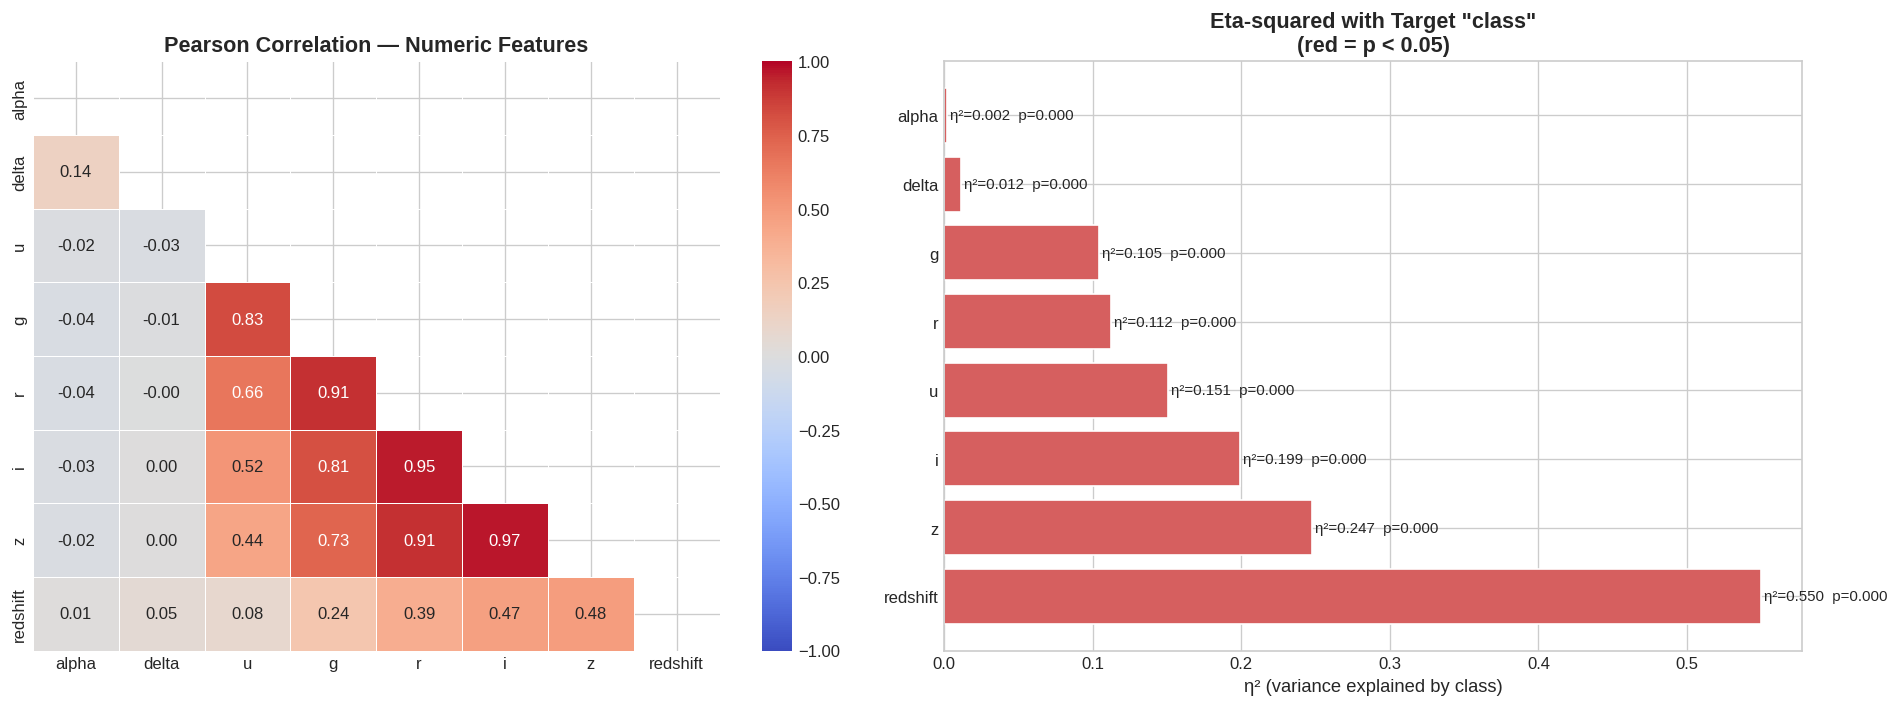

In [49]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Pearson correlation heatmap (unchanged) ---
corr_matrix = df_train[nums].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('Pearson Correlation — Numeric Features', fontweight='bold')

# --- Right: One-way ANOVA F-stat + eta-squared per numeric feature ---
anova_results = {}
target_col = features.target

for col in nums:
    valid = df_train[[col, target_col]].dropna()
    groups = [grp[col].values for _, grp in valid.groupby(target_col)]
    
    # Skip if any group has < 2 samples
    if any(len(g) < 2 for g in groups):
        continue
    
    f_stat, p_val = scipy_stats.f_oneway(*groups)
    
    # Eta-squared: SS_between / SS_total
    grand_mean = valid[col].mean()
    ss_total = ((valid[col] - grand_mean) ** 2).sum()
    ss_between = sum(
        len(g) * (g.mean() - grand_mean) ** 2 for g in groups
    )
    eta_sq = ss_between / ss_total if ss_total > 0 else 0.0
    
    anova_results[col] = {
        'f_stat': round(f_stat, 4),
        'p_value': round(p_val, 6),
        'eta_sq': round(eta_sq, 4)
    }

anova_df = pd.DataFrame(anova_results).T.sort_values('eta_sq', ascending=False)
print(f'=== ANOVA F-stat + Eta-squared with target "{target_col}" ===')
print(anova_df)

# Bar chart of eta-squared (always 0–1, so no negative bars)
colors_anova = ['#D65F5F' if p < 0.05 else '#AAAAAA' for p in anova_df['p_value']]
axes[1].barh(anova_df.index, anova_df['eta_sq'], color=colors_anova, edgecolor='white')
axes[1].set_title(f'Eta-squared with Target "{target_col}"\n(red = p < 0.05)', fontweight='bold')
axes[1].set_xlabel('η² (variance explained by class)')

for i, (idx, row) in enumerate(anova_df.iterrows()):
    axes[1].text(row['eta_sq'] + 0.002, i, f"η²={row['eta_sq']:.3f}  p={row['p_value']:.3f}",
                 va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

u-g, g-r, g-i, r-i, r-z, i-z

In [50]:
from scipy.stats import chi2_contingency

def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Cramér's V for two categorical Series."""
    ct = pd.crosstab(x, y)

    r, k = ct.shape
    if r < 2 or k < 2:
        return 0.0

    chi2, _, _, _ = chi2_contingency(ct, correction=False)
    n = ct.to_numpy().sum()
    phi2 = chi2 / n
    denom = min(r - 1, k - 1)
    if denom == 0:
        return 0.0

    return float(np.sqrt(phi2 / denom))

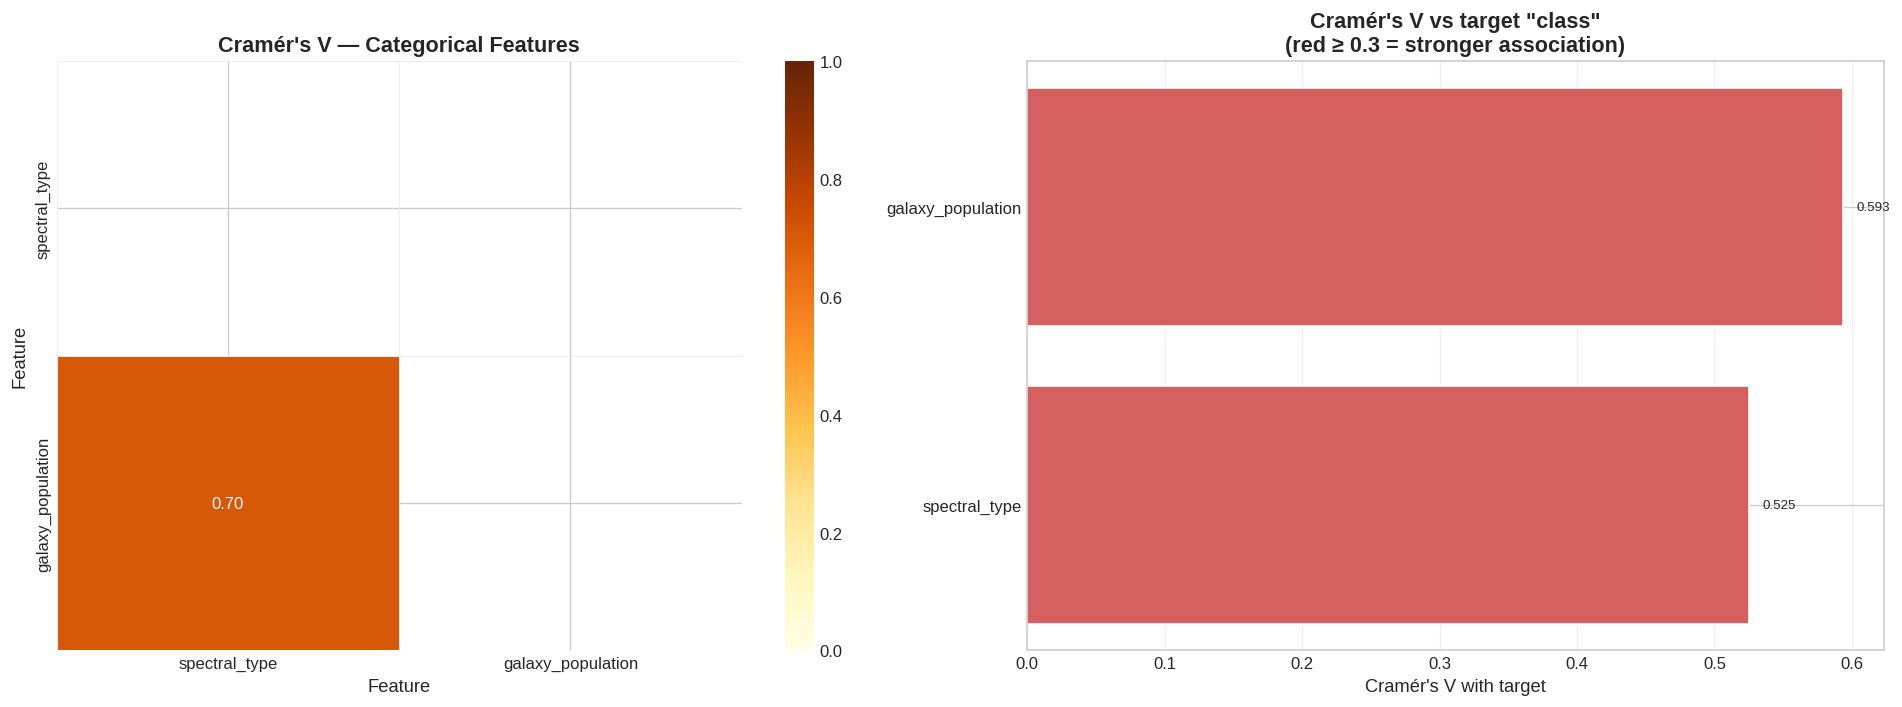

In [51]:
target_col = features.target
cat_cols = [c for c in cats if c != target_col]

# ── 1. Cramér's V matrix between categorical features ────────────────
n = len(cat_cols)
cv_matrix = pd.DataFrame(
    np.zeros((n, n), dtype=float),
    index=cat_cols,
    columns=cat_cols,
)

for i, col_i in enumerate(cat_cols):
    for j, col_j in enumerate(cat_cols):
        if j < i:
            continue
        v = cramers_v(df_train[col_i], df_train[col_j])
        cv_matrix.loc[col_i, col_j] = v
        cv_matrix.loc[col_j, col_i] = v

# ── 2. Cramér's V vs target for ranking ───────────────────────────────
ft_results = []
for col in cat_cols:
    v = cramers_v(df_train[col], df_train[target_col])
    ft_results.append((col, v))

cv_ft = (
    pd.DataFrame(ft_results, columns=["feature", "cramers_v"])
      .sort_values("cramers_v", ascending=False)
)

# ── 3. Plot layout ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Cramér's V heatmap between categorical features
mask = np.triu(np.ones_like(cv_matrix, dtype=bool))
sns.heatmap(
    cv_matrix,
    mask=mask,
    cmap="YlOrBr",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="#eeeeee",
    ax=axes[0],
)
axes[0].set_title("Cramér's V — Categorical Features", fontweight="bold")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Feature")

# Right: Feature–target association strength
colors_cv = ["#D65F5F" if v >= 0.3 else "#AAAAAA" for v in cv_ft["cramers_v"]]
axes[1].barh(
    cv_ft["feature"],
    cv_ft["cramers_v"],
    color=colors_cv,
    edgecolor="white",
)
axes[1].set_xlabel("Cramér's V with target")
axes[1].set_title(
    f'Cramér\'s V vs target "{target_col}"\n(red ≥ 0.3 = stronger association)',
    fontweight="bold",
)
axes[1].invert_yaxis()  # strongest at top
axes[1].grid(axis="x", alpha=0.3)

for i, (feat, val) in enumerate(cv_ft.itertuples(index=False)):
    axes[1].text(val + 0.01, i, f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 9. Initial Observations & Key Takeaways

### Class Imbalance
- There is a clear dominance for the majority class. The smallest class is only 20% of the largest.
- Accuracy will be misleading. 
- Consider class-weighted loss.

### Key Predictive Features
- Based on feature target correlation redshift, galaxy_population and spectral_type seems to be the strongest.
- We have a cluster of highly correlated features `u-g`, `g-r`, `g-i`, `r-i`, `r-z`, `i-z` all score 0.8+.
- `alpha` and `delta` has very low predictive signal and might be dropped.

### Missing Data Patterns
- No missing data


### Skewed and Kurtosis Distributions
- Redshift has both high skew and kurtosis.
- All numeric features are bi- or multimodal except `u`.
- - **Recommended transform:** Log1p transformation: $$x' = \ln(x + 1)$$ to compress the right tail without losing zero values.

### Actionable Next Steps
- Consider modifying dataset. Drop weak features, transform `Redshift`.
- Explore redshift, galaxy_population and spectral_type for interaction features
